In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load and parse dataset
df = pd.read_csv("./global_superstore_2016(Orders).csv", encoding="latin1", low_memory=False)

def clean_currency(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    is_neg = False
    if s.startswith("(") and s.endswith(")"):
        is_neg = True
        s = s[1:-1]
    elif "-" in s:
        is_neg = True
        s = s.replace("-", "")
    s = s.replace("$", "").replace(",", "").strip()
    try:
        n = float(s)
        return -n if is_neg else n
    except:
        return np.nan

df["Sales"] = df["Sales"].apply(clean_currency)
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed")

# Feature engineering
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Year"] = df["Order Date"].dt.year

# Define predictors and target
categorical_features = ["Category", "Sub-Category", "Segment", "Market", "Ship Mode", "Order Priority"]
numerical_features = ["Quantity", "Discount", "Shipping Cost", "Shipping Days", "Order_Month", "Order_Year"]

X = df[categorical_features + numerical_features]
y = df["Sales"]

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Column transformation pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)

In [2]:
# 1. Baseline: Linear Regression
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# 2. Non-linear: Random Forest Regressor
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {name} ---")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : ${mae:.2f}")
    print(f"RMSE     : ${rmse:.2f}\n")

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest Regressor", y_test, y_pred_rf)

--- Linear Regression ---
R² Score : 0.5615
MAE      : $119.60
RMSE     : $366.08

--- Random Forest Regressor ---
R² Score : 0.6515
MAE      : $79.31
RMSE     : $326.36



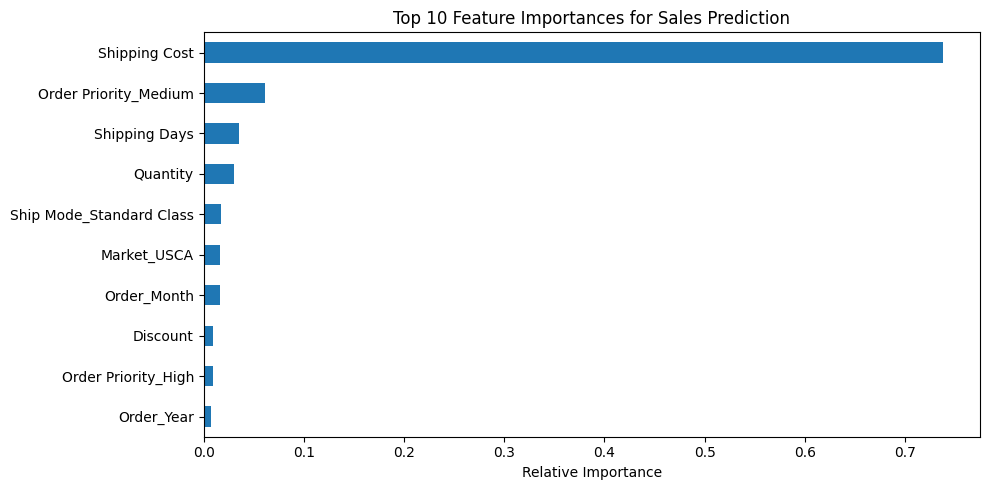

In [3]:
rf_model = rf_pipeline.named_steps["model"]
prep_step = rf_pipeline.named_steps["prep"]

cat_names = prep_step.named_transformers_["cat"].get_feature_names_out(categorical_features).tolist()
all_features = numerical_features + cat_names

importance_df = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance_df.head(10).plot(kind="barh", color="#1f77b4").invert_yaxis()
plt.title("Top 10 Feature Importances for Sales Prediction")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

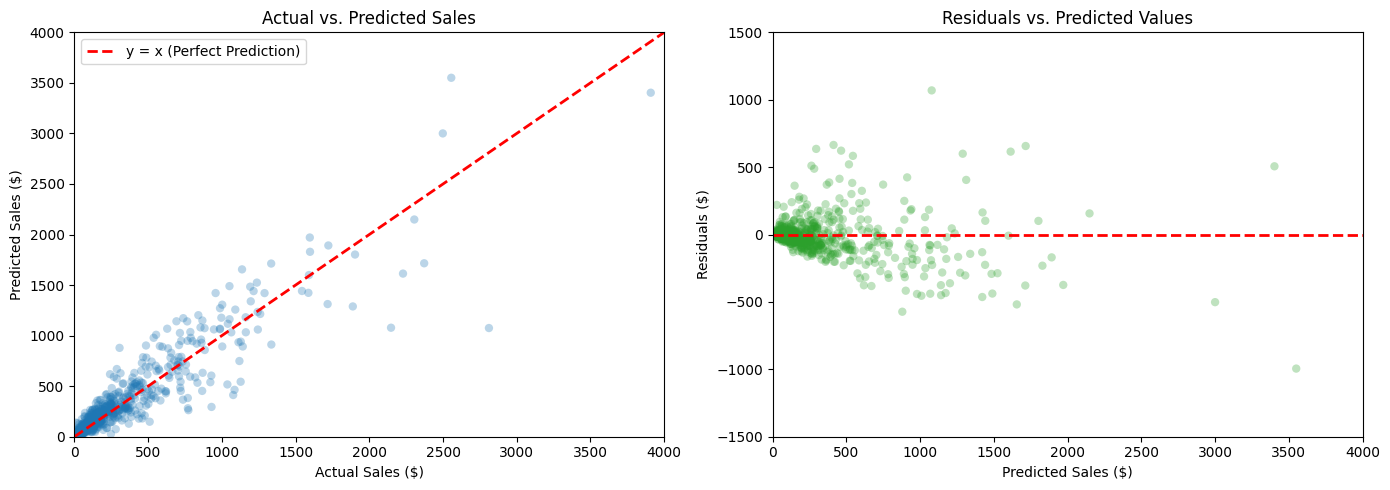

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted Plot
sample_idx = np.random.RandomState(42).choice(len(y_test), size=1000, replace=False)
y_sample = y_test.iloc[sample_idx]
pred_sample = y_pred_rf[sample_idx]

axes[0].scatter(y_sample, pred_sample, alpha=0.3, color="#1f77b4", edgecolors="none")
axes[0].plot([0, 4000], [0, 4000], "r--", lw=2, label="y = x (Perfect Prediction)")
axes[0].set_xlim(0, 4000)
axes[0].set_ylim(0, 4000)
axes[0].set_xlabel("Actual Sales ($)")
axes[0].set_ylabel("Predicted Sales ($)")
axes[0].set_title("Actual vs. Predicted Sales")
axes[0].legend()

# Residual Plot
residuals = y_sample - pred_sample
axes[1].scatter(pred_sample, residuals, alpha=0.3, color="#2ca02c", edgecolors="none")
axes[1].axhline(0, color="r", linestyle="--", lw=2)
axes[1].set_xlim(0, 4000)
axes[1].set_ylim(-1500, 1500)
axes[1].set_xlabel("Predicted Sales ($)")
axes[1].set_ylabel("Residuals ($)")
axes[1].set_title("Residuals vs. Predicted Values")

plt.tight_layout()
plt.show()